Modern deep learning frameworks abstract away the mechanics of training. In the previous notebooks I created a LinearLayer and ReLU, which I am going to reuse. Then I defined a softmax activation function and cross entropy loss, which again I am going to reuse. In this notebook I will show a simple train/test split, explain that it is not enough, and create a K-fold cross validation. I will also finally build a model wrapper class. I will use them to classify the Iris dataset and verify that the model generalizes well.

# Importing libraries

In [1]:
# importing libraries
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass

# Helper functions and classes

In [2]:
# --- Colab setup (ignore if running locally) ---
if not Path("/content/ml-from-scratch").exists():
  !git clone https://github.com/vmirchev/ml-from-scratch.git

Cloning into 'ml-from-scratch'...
remote: Enumerating objects: 41, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (30/30), done.
remote: Total 41 (delta 13), reused 35 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (41/41), 218.00 KiB | 5.45 MiB/s, done.
Resolving deltas: 100% (13/13), done.


In [3]:
import sys

# --- Colab setup (ignore if running locally) ---
# add the project root to the system path if not already present
project_root = Path("/content/ml-from-scratch")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.layers import LinearLayer
from src.activations import ReLU
from src.losses import CrossEntropyLoss
from src.preprocessing import ZScoreNormalization
from src.utils import one_hot_encode
from src.utils import create_batches
from src.utils import set_seeds

In [4]:
# set seeds for reproducibility
seed = 42
set_seeds(seed)

In [5]:
# adding val_loss and val_accuracies
def plot_training_curves(train_losses, train_accuracies, val_losses=None, val_accuracies=None):
  fig, axes = plt.subplots(1, 2, figsize=(14, 6))

  # plot for Loss
  axes[0].plot(train_losses, label='Train Loss')
  if val_losses is not None:
      axes[0].plot(val_losses, label='Val Loss', linestyle='--')

  axes[0].set_title('Loss Over Epochs')
  axes[0].set_xlabel('Epoch')
  axes[0].set_ylabel('Loss')
  axes[0].legend()
  axes[0].grid(True)

  # plot for Accuracy
  axes[1].plot(train_accuracies, label='Train Accuracy')
  if val_accuracies is not None:
      axes[1].plot(val_accuracies, label='Val Accuracy', linestyle='--')

  axes[1].set_title('Accuracy Over Epochs')
  axes[1].set_xlabel('Epoch')
  axes[1].set_ylabel('Accuracy')
  axes[1].legend()
  axes[1].grid(True)

  plt.tight_layout() # adjust layout to prevent overlapping titles
  plt.show()

# Loading the IRIS Dataset

In [6]:
candidate_paths = [
    Path("ml-from-scratch") / "data" / "iris_with_targets.csv",
    Path("data") / "iris_with_targets.csv",
]

csv_path = next((p for p in candidate_paths if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError("Could not find iris_with_targets.csv")

iris_df = pd.read_csv(csv_path)
print(f"Successfully loaded '{csv_path}' into a pandas DataFrame.")
iris_df.head()

Successfully loaded 'ml-from-scratch/data/iris_with_targets.csv' into a pandas DataFrame.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,target_names
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


# Creating a model wrapper

Well so far we have not defined a structure for our models. To be able to continue development with a bit of ease I will create a model wrapper. It is going to be pretty simple. A Model class with a list of layers. Then when calling model.forward() it will run a forward pass, then when calling backward(loss) it will calculate the gradient and a step() method will update the gradients.

In [7]:
class Model:
    def __init__(self, layers=None):
      self.layers = []
      if layers:
          self.add_all(layers)

    def add(self, layer):
      self.layers.append(layer)

    def add_all(self, layers):
      self.layers.extend(layers)

    def forward(self, x):
      for layer in self.layers:
          x = layer.forward(x)
      return x

    def backward(self, grad):
      # iterate backward through the layers
      for layer in reversed(self.layers):
          grad = layer.backward(grad)
      return grad

    def step(self, lr):
      # call step only on layers that have learnable parameters
      for layer in self.layers:
          if hasattr(layer, 'step'):
              layer.step(lr)

# Validation loop

Well before we do a propper split I will create a helper function that will do an evaluation and return accuracy. It is pretty close to the original training loop, but when mixed together they seem confusing. So I really like separating them.

In [8]:
def evaluate_classification_model(model, loss_fn, X_test, y_test, batch_size, num_classes):
  if len(X_test) != len(y_test):
    raise ValueError("X_test and y_test must have the same number of samples")

  epoch_test_loss_sum = 0
  epoch_test_correct = 0
  epoch_test_total = 0

  # no need to shuffle test data
  # when evaluating we don't do backprop on the model
  for X_batch_test, y_batch_test in create_batches(X_test, y_test, batch_size, shuffle=False):
      y_true_one_hot_test = one_hot_encode(y_batch_test, num_classes=num_classes)

      logits_test = model.forward(X_batch_test)
      batch_test_loss = loss_fn.forward(logits_test, y_true_one_hot_test)
      epoch_test_loss_sum += batch_test_loss * len(y_batch_test)

      predictions_test = np.argmax(loss_fn.softmax_output, axis=1)
      epoch_test_correct += np.sum(predictions_test == y_batch_test)
      epoch_test_total += len(y_batch_test)

  test_loss = epoch_test_loss_sum / epoch_test_total
  test_accuracy = epoch_test_correct / epoch_test_total
  return test_loss, test_accuracy

# Train test split

So far we have a model that is learning the features of the iris dataset. But the model might memorize the training data instead of actually learning patterns.

For that reason before making conclusions about the model, we should test it on unseen data. In practice this is usally done in 3 sets - a train, validation and test set but for the purpuses of this notebook a simple train validation split should be enough.

But first let us shuffle the data.

In [9]:
feature_columns = iris_df.columns[:4]
target_column = iris_df.columns[4]
target_name_column = iris_df.columns[5]

shuffled_iris_df = iris_df.sample(frac=1, random_state=seed).reset_index(drop=True)

features = shuffled_iris_df[feature_columns].to_numpy(dtype=np.float32)
targets = shuffled_iris_df[target_column].to_numpy(dtype=np.int64)
target_names_map = dict(shuffled_iris_df[[target_column, target_name_column]].drop_duplicates().values)

print("Features shape:", features.shape)
print("Targets shape:", targets.shape)

Features shape: (150, 4)
Targets shape: (150,)


Now sklearn has a beautifull function [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), which includes a stratify param. If used, data is split in a stratified fashion, using stratisfy param value as the class labels.

I highly recommend using it instead of a manual split, but for the purpuses of this notebook a 20% manual split on shuffled data is fine.

In [10]:
test_size = 0.2
num_samples = features.shape[0]
split_index = int(num_samples * (1 - test_size))

X_train, X_val = features[:split_index], features[split_index:]
y_train, y_val = targets[:split_index], targets[split_index:]

print(f"Training set size: {len(X_train)} samples")
print(f"Validation set size: {len(X_val)} samples")
print("-----")
print("Make sure all 3 classes are present")
print("Train class counts:", np.bincount(y_train))
print("Validation class counts:", np.bincount(y_val))

Training set size: 120 samples
Validation set size: 30 samples
-----
Make sure all 3 classes are present
Train class counts: [43 39 38]
Validation class counts: [ 7 11 12]


# Data leakage

A really important note here is to avoid a hidden data leakage. We need to standartize the data based on the train set, not the whole dataset to avoid leaking validation data in the train set.

In [11]:
data_normalization = ZScoreNormalization()
X_train = data_normalization.fit_transform(X_train)
X_val = data_normalization.transform(X_val)

# Full training loop

This is now a full training loop with the Model wrapper, using the evaluate_classification_model function.

In [12]:
@dataclass
class TrainingConfig:
    epochs: int = 1500
    batch_size: int = 16
    learning_rate: float = 0.01
    num_classes: int = 3

    print_debug: bool = False

In [13]:
def train_model(model, loss_fn, X_train, y_train, X_val, y_val, cfg: TrainingConfig):
  train_losses = []
  train_accuracies = []
  val_losses = []
  val_accuracies = []

  for epoch in range(cfg.epochs):
    # Training phase
    epoch_train_loss_sum = 0
    epoch_train_correct = 0
    epoch_train_total = 0

    for X_batch, y_batch in create_batches(X_train, y_train, cfg.batch_size):
      y_true_one_hot = one_hot_encode(y_batch, num_classes=cfg.num_classes)

      # forward pass
      logits = model.forward(X_batch)

      # calculate the loss
      batch_loss = loss_fn.forward(logits, y_true_one_hot)
      epoch_train_loss_sum += batch_loss * len(y_batch)

      # calculate accuracy
      predictions = np.argmax(loss_fn.softmax_output, axis=1)
      epoch_train_correct += np.sum(predictions == y_batch)

      # update total count
      epoch_train_total += len(y_batch)

      # derivative of loss fn
      grad_logits = loss_fn.backward()

      # gradient descent
      model.backward(grad_logits)
      model.step(cfg.learning_rate)

    train_loss = epoch_train_loss_sum / epoch_train_total
    train_losses.append(train_loss)

    train_accuracy = epoch_train_correct / epoch_train_total
    train_accuracies.append(train_accuracy)

    # make an evaluation run
    val_loss, val_accuracy = evaluate_classification_model(model, loss_fn, X_val, y_val, cfg.batch_size, cfg.num_classes)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    if epoch % 100 == 0 and cfg.print_debug:
        print(
            f"Epoch {epoch:4d} | "
            f"train_loss={train_loss:.4f} | train_acc={train_accuracy:.4f} | "
            f"val_loss={val_loss:.4f} | val_acc={val_accuracy:.4f}"
        )

  return train_losses, train_accuracies, val_losses, val_accuracies

Epoch    0 | train_loss=2.2559 | train_acc=0.0500 | val_loss=1.9367 | val_acc=0.1000
Epoch  100 | train_loss=0.2216 | train_acc=0.9000 | val_loss=0.3493 | val_acc=0.9000
Epoch  200 | train_loss=0.1090 | train_acc=0.9583 | val_loss=0.2273 | val_acc=0.9333
Epoch  300 | train_loss=0.0731 | train_acc=0.9750 | val_loss=0.1922 | val_acc=0.9333
Epoch  400 | train_loss=0.0590 | train_acc=0.9750 | val_loss=0.1781 | val_acc=0.9333
Epoch  500 | train_loss=0.0507 | train_acc=0.9833 | val_loss=0.1738 | val_acc=0.9333
Epoch  600 | train_loss=0.0473 | train_acc=0.9833 | val_loss=0.1778 | val_acc=0.9333
Epoch  700 | train_loss=0.0444 | train_acc=0.9833 | val_loss=0.1905 | val_acc=0.9333
Epoch  800 | train_loss=0.0427 | train_acc=0.9833 | val_loss=0.1934 | val_acc=0.9333
Epoch  900 | train_loss=0.0421 | train_acc=0.9833 | val_loss=0.1974 | val_acc=0.9333
Epoch 1000 | train_loss=0.0405 | train_acc=0.9833 | val_loss=0.2068 | val_acc=0.9333
Epoch 1100 | train_loss=0.0398 | train_acc=0.9833 | val_loss=0.22

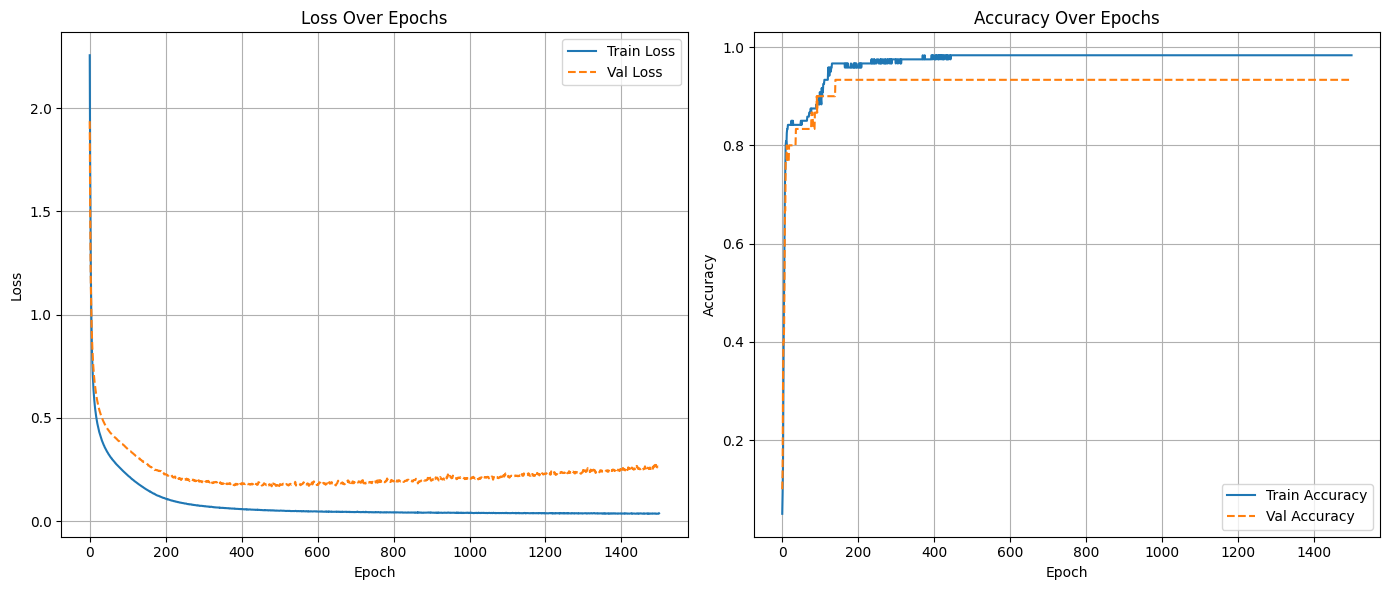

Final train loss: 0.0383
Final train accuracy: 0.9833
Final val loss: 0.2590
Final val accuracy: 0.9333


In [14]:
layers = [LinearLayer(in_features=4, out_features=16),
ReLU(),
LinearLayer(in_features=16, out_features=16),
ReLU(),
LinearLayer(in_features=16, out_features=3)]

model = Model(layers)

loss_fn = CrossEntropyLoss()

# Create a TrainingConfig instance
cfg = TrainingConfig(
    epochs=1500,
    batch_size=16,
    learning_rate=0.01,
    num_classes=len(np.unique(targets)),
    print_debug=True
)

train_losses, train_accuracies, val_losses, val_accuracies = train_model(
    model, loss_fn, X_train, y_train, X_val, y_val, cfg
)

plot_training_curves(train_losses, train_accuracies, val_losses, val_accuracies)

print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final train accuracy: {train_accuracies[-1]:.4f}")
print(f"Final val loss: {val_losses[-1]:.4f}")
print(f"Final val accuracy: {val_accuracies[-1]:.4f}")

# # K-fold cross-validation

When we use a single random train-test split, the evaluation can be unreliable because the split might be unusually favorable or unfavorable by chance, leading to misleading performance estimates. Especially in small datasets like IRIS.

The dataset is split into $K$ folds (e.g., 5 or 10). The model trains on $K-1$ folds and validates on the remaining fold, repeating this $K$ times so each fold acts as validation once.

This image usually clarifies it even further. It is a comparison between normal train test split, and k-fold validation.

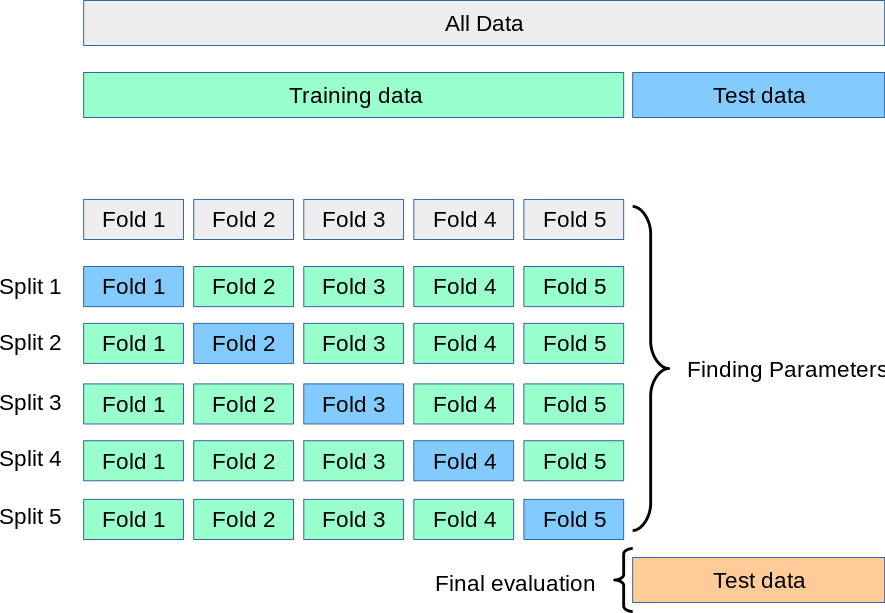

In [15]:
def k_fold_split(X, y, k=5, shuffle=True):
  if k <= 1:
    raise ValueError("k must be greater than 1")
  if k > len(X):
      raise ValueError("k cannot be greater than the number of samples")
  if len(X) != len(y):
      raise ValueError("X and y must have the same number of samples")

  num_samples = X.shape[0]

  # similar to create batches we can shuffle data
  indices = np.arange(num_samples)

  if shuffle:
      np.random.shuffle(indices)

  fold_sizes = np.full(k, num_samples // k, dtype=int)
  fold_sizes[:num_samples % k] += 1
  current = 0

  # create folds exactly as in the example images
  for fold_size in fold_sizes:
      start, stop = current, current + fold_size
      val_indices = indices[start:stop]
      train_indices = np.concatenate((indices[:start], indices[stop:]))
      yield train_indices, val_indices
      current = stop


In [16]:
k_folds = 5
set_seeds(seed)

# Create a TrainingConfig instance outside the loop
cfg = TrainingConfig(
    epochs=1500,
    batch_size=16,
    learning_rate=0.01,
    num_classes=len(np.unique(targets)) # num_classes should be based on the full dataset
)

all_fold_train_losses = []
all_fold_train_accuracies = []
all_fold_val_losses = []
all_fold_val_accuracies = []

for fold, (train_indices, val_indices) in enumerate(k_fold_split(features, targets, k=k_folds, shuffle=True)):
    print(f"\n--- Fold {fold + 1}/{k_folds} ---")

    X_train_fold, X_val_fold = features[train_indices], features[val_indices]
    y_train_fold, y_val_fold = targets[train_indices], targets[val_indices]

    # normalize data for each fold separately to prevent data leakage
    data_normalization = ZScoreNormalization()
    X_train_fold = data_normalization.fit_transform(X_train_fold)
    X_val_fold = data_normalization.transform(X_val_fold)

    # re-initialize model and loss function for each fold
    layers = [LinearLayer(in_features=4, out_features=16),
              ReLU(),
              LinearLayer(in_features=16, out_features=16),
              ReLU(),
              LinearLayer(in_features=16, out_features=3)]

    model = Model(layers)

    # use crossentropy as loss function
    loss_fn = CrossEntropyLoss()

    # train the model for the current fold
    fold_train_losses, fold_train_accuracies, fold_val_losses, fold_val_accuracies = train_model(
        model, loss_fn, X_train_fold, y_train_fold, X_val_fold, y_val_fold, cfg
    )

    all_fold_train_losses.append(fold_train_losses)
    all_fold_train_accuracies.append(fold_train_accuracies)
    all_fold_val_losses.append(fold_val_losses)
    all_fold_val_accuracies.append(fold_val_accuracies)

    print(f"Fold {fold + 1} Final Train Loss: {fold_train_losses[-1]:.4f}")
    print(f"Fold {fold + 1} Final Train Accuracy: {fold_train_accuracies[-1]:.4f}")
    print(f"Fold {fold + 1} Final Val Loss: {fold_val_losses[-1]:.4f}")
    print(f"Fold {fold + 1} Final Val Accuracy: {fold_val_accuracies[-1]:.4f}")

def mean_final_metric(all_fold_metrics):
    return np.mean([fold_metrics[-1] for fold_metrics in all_fold_metrics])

def std_final_metric(all_fold_metrics):
    return np.std([fold_metrics[-1] for fold_metrics in all_fold_metrics])

mean_final_train_loss = mean_final_metric(all_fold_train_losses)
mean_final_train_accuracy = mean_final_metric(all_fold_train_accuracies)
mean_final_val_loss = mean_final_metric(all_fold_val_losses)
mean_final_val_accuracy = mean_final_metric(all_fold_val_accuracies)
std_final_val_accuracy = std_final_metric(all_fold_val_accuracies)

print(f"\n--- Average Metrics Across {k_folds} Folds ---")
print(f"Average Final Train Loss: {mean_final_train_loss:.4f}")
print(f"Average Final Train Accuracy: {mean_final_train_accuracy:.4f}")
print(f"Average Final Val Loss: {mean_final_val_loss:.4f}")
print(f"Average Final Val Accuracy: {mean_final_val_accuracy:.4f} +/- {std_final_val_accuracy:.4f}")


--- Fold 1/5 ---
Fold 1 Final Train Loss: 0.0298
Fold 1 Final Train Accuracy: 0.9833
Fold 1 Final Val Loss: 0.0078
Fold 1 Final Val Accuracy: 1.0000

--- Fold 2/5 ---
Fold 2 Final Train Loss: 0.0402
Fold 2 Final Train Accuracy: 0.9917
Fold 2 Final Val Loss: 0.0826
Fold 2 Final Val Accuracy: 0.9667

--- Fold 3/5 ---
Fold 3 Final Train Loss: 0.0188
Fold 3 Final Train Accuracy: 1.0000
Fold 3 Final Val Loss: 0.1242
Fold 3 Final Val Accuracy: 0.9333

--- Fold 4/5 ---
Fold 4 Final Train Loss: 0.0189
Fold 4 Final Train Accuracy: 0.9917
Fold 4 Final Val Loss: 0.1721
Fold 4 Final Val Accuracy: 0.9000

--- Fold 5/5 ---
Fold 5 Final Train Loss: 0.0071
Fold 5 Final Train Accuracy: 1.0000
Fold 5 Final Val Loss: 0.3831
Fold 5 Final Val Accuracy: 0.9000

--- Average Metrics Across 5 Folds ---
Average Final Train Loss: 0.0229
Average Final Train Accuracy: 0.9933
Average Final Val Loss: 0.1539
Average Final Val Accuracy: 0.9400 +/- 0.0389


As seen here, we may occasionally achieve a validation accuracy of 100%. However, with different splits of the data, the results can vary significantly. This shows that relying on a single train-test split, especially with a small dataset, is not reliable.

In the next notebook I will explore a new dataset and more regularization techniques.